--- PA Debug Info ---
PA Saturation Amplitude (Asat): 1.283012
Input -50dBm -> Amplitude: 0.000094
Output @ -50dBm input -> Amplitude: 0.000944


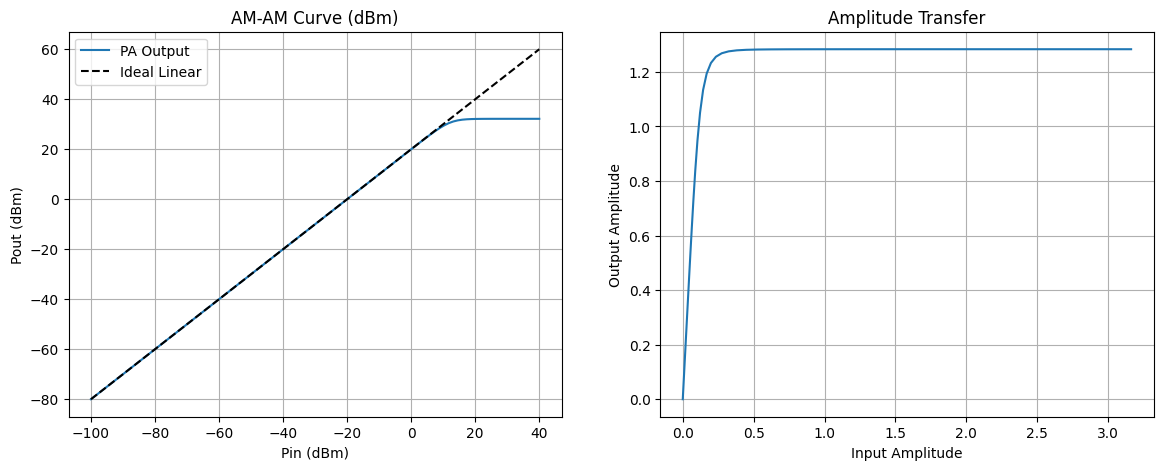

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.rf.PA import PABlock, PAParams
from rfmodel.core.signal import Signal
from rfmodel.core.units import dbm_to_w, w_to_dbm

# 1. Setup a "Linear-ish" PA
# We use Gain=0dB so Input Amplitude should EQUAL Output Amplitude
pa_params = PAParams(
    gain_db=20.0,       
    p1db_out_dbm=30.0,  # 1 Watt saturation
    smoothness_p=2.0
)
pa = PABlock("Debug_PA", pa_params)

# --------------------------------------------------
# 2. Create a range of input powers in dBm
# --------------------------------------------------
p_in_dbm = np.linspace(-100, 40, 100)

# Instead of passing the whole array, we convert one by one
# because your current dbm_to_w doesn't support arrays
a_in = [np.sqrt(dbm_to_w(p)) for p in p_in_dbm]

# --------------------------------------------------
# 3. Process and measure
# --------------------------------------------------
a_out = []
p_out_dbm = []

for amp in a_in:
    s_in = Signal(x=np.array([amp + 0j]), fs_hz=20e6)
    s_out = pa.process(s_in)
    
    amp_out = np.abs(s_out.x[0])
    a_out.append(amp_out)
    
    # Using w_to_dbm here - if it also crashes, 
    # use w_to_dbm(float(amp_out**2))
    p_out_dbm.append(w_to_dbm(amp_out**2))
# 3. Process and measure
a_out = []
p_out_dbm = []

for amp in a_in:
    s_in = Signal(x=np.array([amp + 0j]), fs_hz=20e6)
    s_out = pa.process(s_in)
    
    amp_out = np.abs(s_out.x[0])
    a_out.append(amp_out)
    p_out_dbm.append(w_to_dbm(amp_out**2))

# 4. Diagnostics
print(f"--- PA Debug Info ---")
print(f"PA Saturation Amplitude (Asat): {pa.Asat:.6f}")
print(f"Input -50dBm -> Amplitude: {a_in[np.argmin(np.abs(p_in_dbm + 50))]:.6f}")
print(f"Output @ -50dBm input -> Amplitude: {a_out[np.argmin(np.abs(p_in_dbm + 50))]:.6f}")

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot AM-AM (Power)
ax1.plot(p_in_dbm, p_out_dbm, label='PA Output')
ax1.plot(p_in_dbm, p_in_dbm + pa_params.gain_db, '--k', label='Ideal Linear')
ax1.set_title("AM-AM Curve (dBm)")
ax1.set_xlabel("Pin (dBm)")
ax1.set_ylabel("Pout (dBm)")
ax1.grid(True)
ax1.legend()

# Plot Amplitude Relationship
ax2.plot(a_in, a_out)
ax2.set_title("Amplitude Transfer")
ax2.set_xlabel("Input Amplitude")
ax2.set_ylabel("Output Amplitude")
ax2.grid(True)

plt.show()